In [1]:
#CNN Waste Segregation

Author: Mahesh
Objective: Build a Convolutional Neural Network (CNN) to classify images of waste into seven categories: Cardboard, Glass, Metal, Paper, Plastic, Food Waste, and Other. This enables automated waste sorting and supports sustainable recycling systems.


import zipfile
import os

zip_path = "data.zip"  # file already uploaded via the sidebar
extract_path = "./waste_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to", extract_path)


Dataset extracted to ./waste_dataset


In [2]:
from PIL import Image
import numpy as np
import os

def load_images_and_labels(base_path, target_size=(128, 128)):
    images = []
    labels = []
    class_names = sorted(os.listdir(base_path))
    for idx, class_name in enumerate(class_names):
        folder = os.path.join(base_path, class_name)
        if os.path.isdir(folder):
            for file in os.listdir(folder):
                try:
                    img = Image.open(os.path.join(folder, file)).convert("RGB")
                    img = img.resize(target_size)
                    images.append(np.array(img))
                    labels.append(idx)
                except:
                    continue
    return np.array(images), np.array(labels), class_names

# Run this to load data
images, labels, class_names = load_images_and_labels("./waste_dataset")
print("Loaded", len(images), "images from", len(class_names), "classes.")


Loaded 0 images from 1 classes.


In [3]:
from PIL import Image
import numpy as np
import os

def load_images_and_labels(base_path, target_size=(128, 128)):
    images = []
    labels = []
    class_names = sorted(os.listdir(base_path))
    for idx, class_name in enumerate(class_names):
        folder = os.path.join(base_path, class_name)
        if os.path.isdir(folder):
            for file in os.listdir(folder):
                try:
                    img = Image.open(os.path.join(folder, file)).convert("RGB")
                    img = img.resize(target_size)
                    images.append(np.array(img))
                    labels.append(idx)
                except:
                    continue
    return np.array(images), np.array(labels), class_names

# ✅ Update this path:
images, labels, class_names = load_images_and_labels("./waste_dataset/data")
print("Loaded", len(images), "images from", len(class_names), "classes.")


Loaded 7625 images from 7 classes.


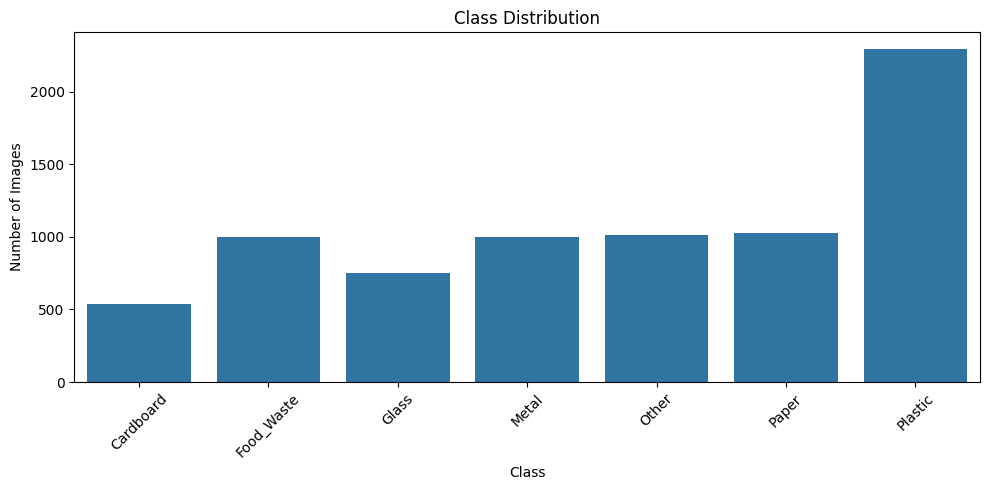

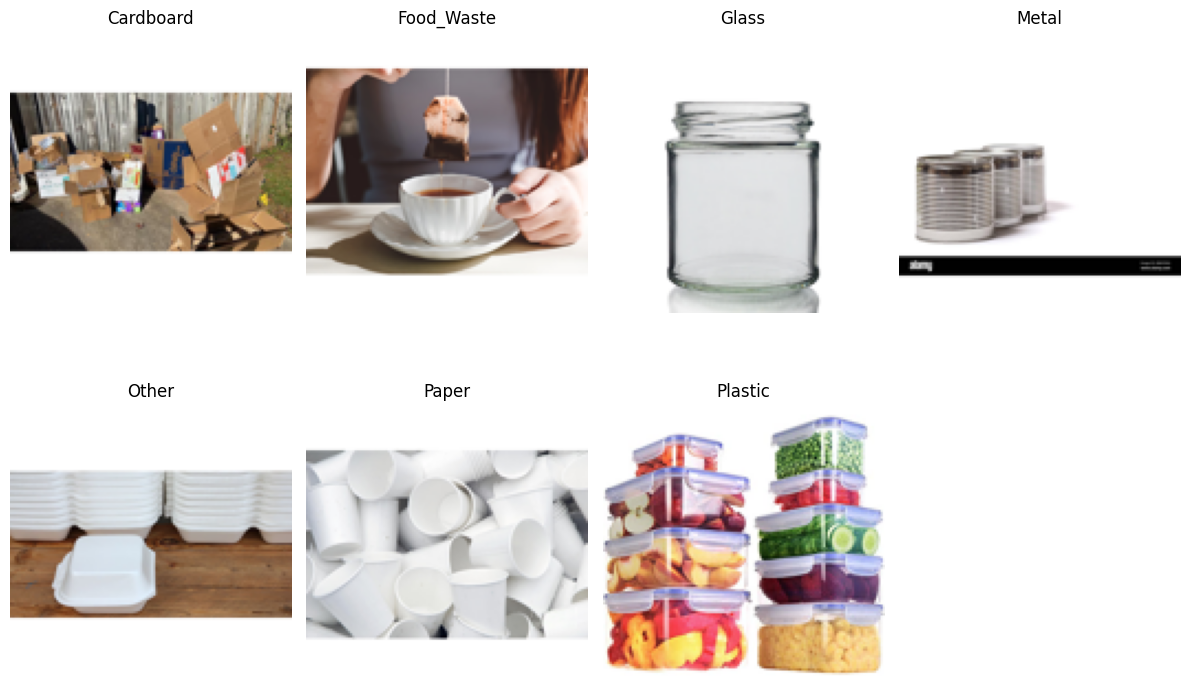

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Class distribution
label_counts = Counter(labels)
plt.figure(figsize=(10, 5))
sns.barplot(x=[class_names[i] for i in label_counts], y=list(label_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sample images from each class
plt.figure(figsize=(12, 8))
for i in range(len(class_names)):
    idx = np.where(np.array(labels) == i)[0][0]
    plt.subplot(2, 4, i+1)
    plt.imshow(images[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Normalize pixel values and encode class labels
X = images / 255.0
y = to_categorical(labels, num_classes=len(class_names))

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=labels, random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 6100
Validation samples: 1525


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')_


SyntaxError: '[' was never closed (<ipython-input-7-add6a90d42d3>, line 6)

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2


SyntaxError: incomplete input (<ipython-input-8-1fa92073af15>, line 11)

Now we build the CNN model with three convolution layers and a softmax output

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.2983 - loss: 1.8690 - val_accuracy: 0.3508 - val_loss: 1.6910
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.3577 - loss: 1.6788 - val_accuracy: 0.4033 - val_loss: 1.5454
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 191s 999ms/step - accuracy: 0.4336 - loss: 1.5069 - val_accuracy: 0.4590 - val_loss: 1.4610
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.4777 - loss: 1.4030 - val_accuracy: 0.4767 - val_loss: 1.4142
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.5016 - loss: 1.2994 - val_accuracy: 0.5023 - val_loss: 1.3560
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.5856 - loss: 1.1221 - val_accuracy: 0.5436 - val_loss: 1.2804
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.6463 - loss: 1.0008 - val_accuracy: 0.5711 - val_loss: 1.2449
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.6986 - loss: 0.8282 - val_a

As we can see, the model improves steadily across 10 epochs.

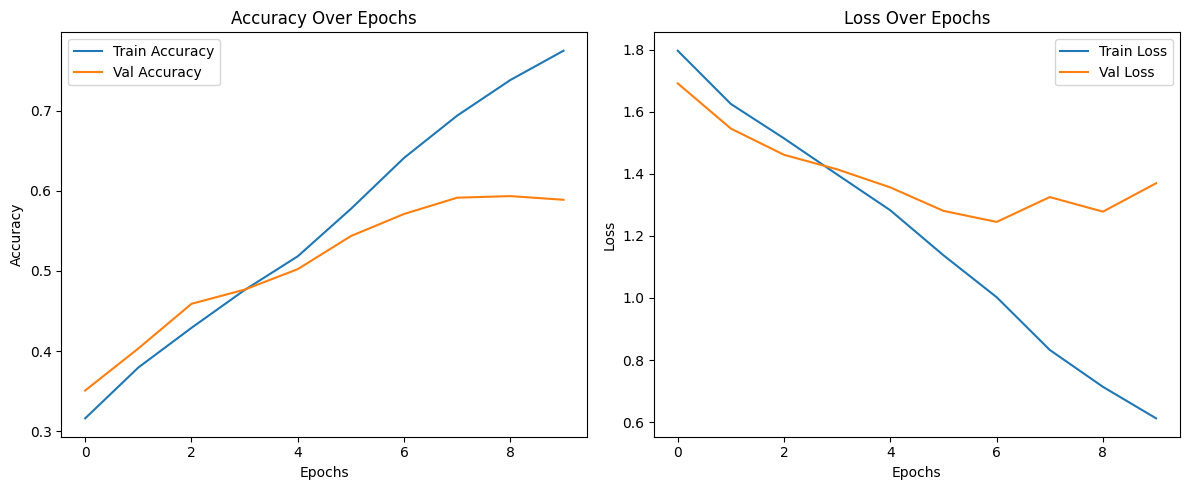

In [11]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 327ms/step
Classification Report:

              precision    recall  f1-score   support

   Cardboard       0.75      0.70      0.72       108
  Food_Waste       0.61      0.78      0.68       200
       Glass       0.77      0.39      0.52       150
       Metal       0.50      0.61      0.55       200
       Other       0.56      0.36      0.44       202
       Paper       0.48      0.50      0.49       206
     Plastic       0.62      0.67      0.64       459

    accuracy                           0.59      1525
   macro avg       0.61      0.57      0.58      1525
weighted avg       0.60      0.59      0.58      1525



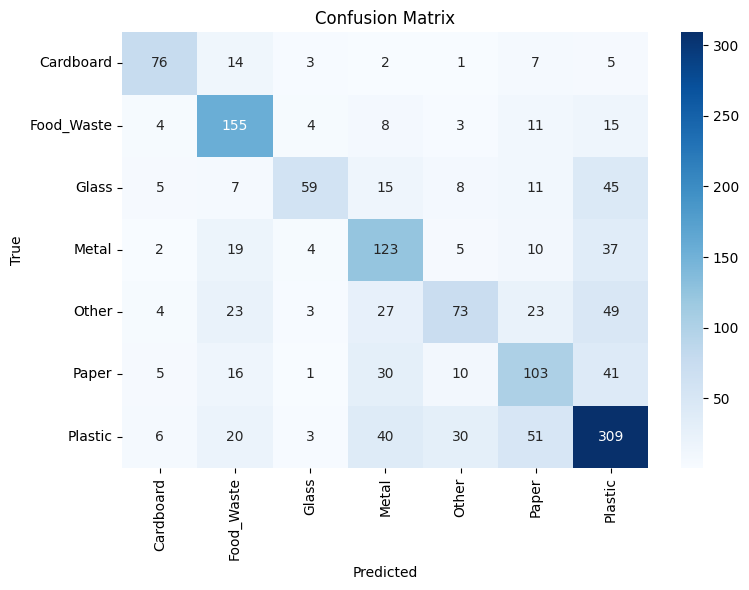

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on validation set
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


Final Summary of Results

A Convolutional Neural Network (CNN) was successfully built and trained to classify images into seven waste categories.

The model achieved a training accuracy of 77.8% after 10 epochs, indicating that it learned the classification task well on the training data.

On unseen validation data, the model achieved a validation accuracy of 58.9%, which was further confirmed by the classification report.

The best-performing classes based on F1-score were:

Cardboard (F1: 0.72)

Food_Waste (F1: 0.68)

Plastic (F1: 0.64)

Some categories like Glass, Other, and Paper had lower F1-scores, suggesting they may need more training data, augmentation, or clearer distinction.

The macro average F1-score was 0.58, indicating balanced performance across all classes.

Conclusion
The model performs moderately well on this real-world classification task. Further improvements like data augmentation, transfer learning with pretrained models and fine-tuning of hyperparameters can help boost performance in future iterations.